In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.4 MB/s eta 0:00:00


In [ ]:
!pip install kmodes

In [ ]:
# --------- 1. Import library ---------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from kmodes.kprototypes import KPrototypes

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data edit 1.xlsx to data edit 1 (1).xlsx
Saving data.xlsx to data (1).xlsx


In [ ]:
import pandas as pd

# === 1. Nama file Anda ===
file1 = "data.xlsx"
file2 = "data edit 1.xlsx"

# === 2. Membaca kedua file Excel ===
df1 = pd.read_excel(file1)
df2 = pd.read_excel(file2)

# === 3. Menyamakan nama kolom jika berbeda penamaan ===
rename_map = {
    "Nama Perusahaan": "nama_perusahaan",
    " Omzet ": "omzet",
    "Omzet": "omzet",
    "Aset": "aset",
    "Jumlah tenaga kerja": "jumlah_tenaga_kerja",
    "Uraian Status Penanaman Modal": "status_penanaman_modal",
    "Uraian Jenis Perusahaan": "jenis_perusahaan",
    "Uraian Risiko Proyek": "risiko_proyek",
    "nama_proyek": "nama_proyek",
    "Uraian Skala Usaha": "skala_usaha",
    "Alamat Usaha": "alamat_usaha",
    "kecamatan_usaha": "kecamatan_usaha",
    "kelurahan_usaha": "kelurahan_usaha",
    "Kbli": "kbli",
    "Judul Kbli": "judul_kbli",
    "KL/Sektor Pembina": "kl_sektor_pembina",
    "Email": "email",
    "Nomor Telp": "nomor_telp",
    "luas_tanah": "luas_tanah",
    "satuan_tanah": "satuan_tanah",
    "Mesin Peralatan": "mesin_peralatan",
    "Mesin Peralatan Impor": "mesin_peralatan_impor",
    "Pembelian Pematangan Tanah": "pembelian_pematangan_tanah",
    "Bangunan Gedung": "bangunan_gedung",
    "Modal Kerja": "modal_kerja",
    "Lain Lain": "lain_lain",
    "Jumlah Investasi": "jumlah_investasi",
    "TKI": "tki"
}

df1.rename(columns=rename_map, inplace=True)
df2.rename(columns=rename_map, inplace=True)

# === 4. Menyamakan seluruh kolom ===
all_cols = sorted(list(set(df1.columns) | set(df2.columns)))
df1 = df1.reindex(columns=all_cols)
df2 = df2.reindex(columns=all_cols)

# === 5. Gabungkan kedua data ke dalam variabel 'df' ===
df = pd.concat([df1, df2], ignore_index=True)



In [ ]:
print("=== Deskripsi Dataset ===")
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom:", df.shape[1])
print("\nNama Kolom :", df.columns.tolist())
print("\nTipe Data Tiap Kolom:\n", df.dtypes)
print("\nRingkasan Statistik Numerik:\n", df.describe())

=== Deskripsi Dataset ===
Jumlah baris : 20857
Jumlah kolom: 28

Nama Kolom : ['Nib', 'alamat_usaha', 'aset', 'bangunan_gedung', 'email', 'jenis_perusahaan', 'judul_kbli', 'jumlah_investasi', 'jumlah_tenaga_kerja', 'kbli', 'kecamatan_usaha', 'kelurahan_usaha', 'kl_sektor_pembina', 'lain_lain', 'luas_tanah', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja', 'nama_perusahaan', 'nama_proyek', 'nomor_telp', 'omzet', 'pembelian_pematangan_tanah', 'risiko_proyek', 'satuan_tanah', 'skala_usaha', 'status_penanaman_modal', 'tki']

Tipe Data Tiap Kolom:
 Nib                            object
alamat_usaha                   object
aset                          float64
bangunan_gedung               float64
email                          object
jenis_perusahaan               object
judul_kbli                     object
jumlah_investasi              float64
jumlah_tenaga_kerja             int64
kbli                           object
kecamatan_usaha                object
kelurahan_usaha       

In [ ]:
# Ubah dulu ke angka jika bisa, yang tidak valid → NaN
df["Nib"] = pd.to_numeric(df["Nib"], errors="coerce")
df["kbli"] = pd.to_numeric(df["kbli"], errors="coerce")

# Lalu ubah ke string (NaN → "")
df["Nib"] = df["Nib"].fillna("").astype(str)
df["kbli"] = df["kbli"].fillna("").astype(str)

# Opsional: jika ada nilai NaN → ubah ke string kosong atau "NA"
df["Nib"] = df["Nib"].replace("<NA>", "")
df["kbli"] = df["kbli"].replace("<NA>", "")

# === 2. Memisahkan fitur numerik dan non-numerik ===
numerik = df.select_dtypes(include=["float64", "int64"])
non_numerik = df.select_dtypes(exclude=["float64", "int64"])

print("=== Kolom Numerik ===")
print(numerik.columns)

print("\n=== Kolom Non-Numerik ===")
print(non_numerik.columns)


=== Kolom Numerik ===
Index(['aset', 'bangunan_gedung', 'jumlah_investasi', 'jumlah_tenaga_kerja',
       'lain_lain', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja',
       'omzet', 'pembelian_pematangan_tanah', 'tki'],
      dtype='object')

=== Kolom Non-Numerik ===
Index(['Nib', 'alamat_usaha', 'email', 'jenis_perusahaan', 'judul_kbli',
       'kbli', 'kecamatan_usaha', 'kelurahan_usaha', 'kl_sektor_pembina',
       'luas_tanah', 'nama_perusahaan', 'nama_proyek', 'nomor_telp',
       'risiko_proyek', 'satuan_tanah', 'skala_usaha',
       'status_penanaman_modal'],
      dtype='object')


=== Kolom Numerik ===
['aset', 'bangunan_gedung', 'jumlah_investasi', 'jumlah_tenaga_kerja', 'lain_lain', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja', 'omzet', 'pembelian_pematangan_tanah', 'tki']

=== Kolom Kategorikal ===
['jenis_perusahaan', 'risiko_proyek', 'skala_usaha', 'status_penanaman_modal', 'kecamatan_usaha', 'kelurahan_usaha', 'kl_sektor_pembina', 'judul_kbli']

=== Statistik Deskriptif Numerik ===
                              count          mean           std       min  \
aset                         3650.0  3.257092e+07  1.379441e+08       0.0   
bangunan_gedung              3869.0  1.760913e+07  6.458219e+08       0.0   
jumlah_investasi             3962.0  6.492114e+08  3.652784e+10  500000.0   
jumlah_tenaga_kerja         20857.0  3.195426e+00  2.975973e+00       0.0   
lain_lain                    3940.0  7.242519e+06  7.840875e+07       0.0   
mesin_peralatan              3940.0  4.809509e+08  3.004088e+10       0.0   
mesin_peralatan_impor        3869

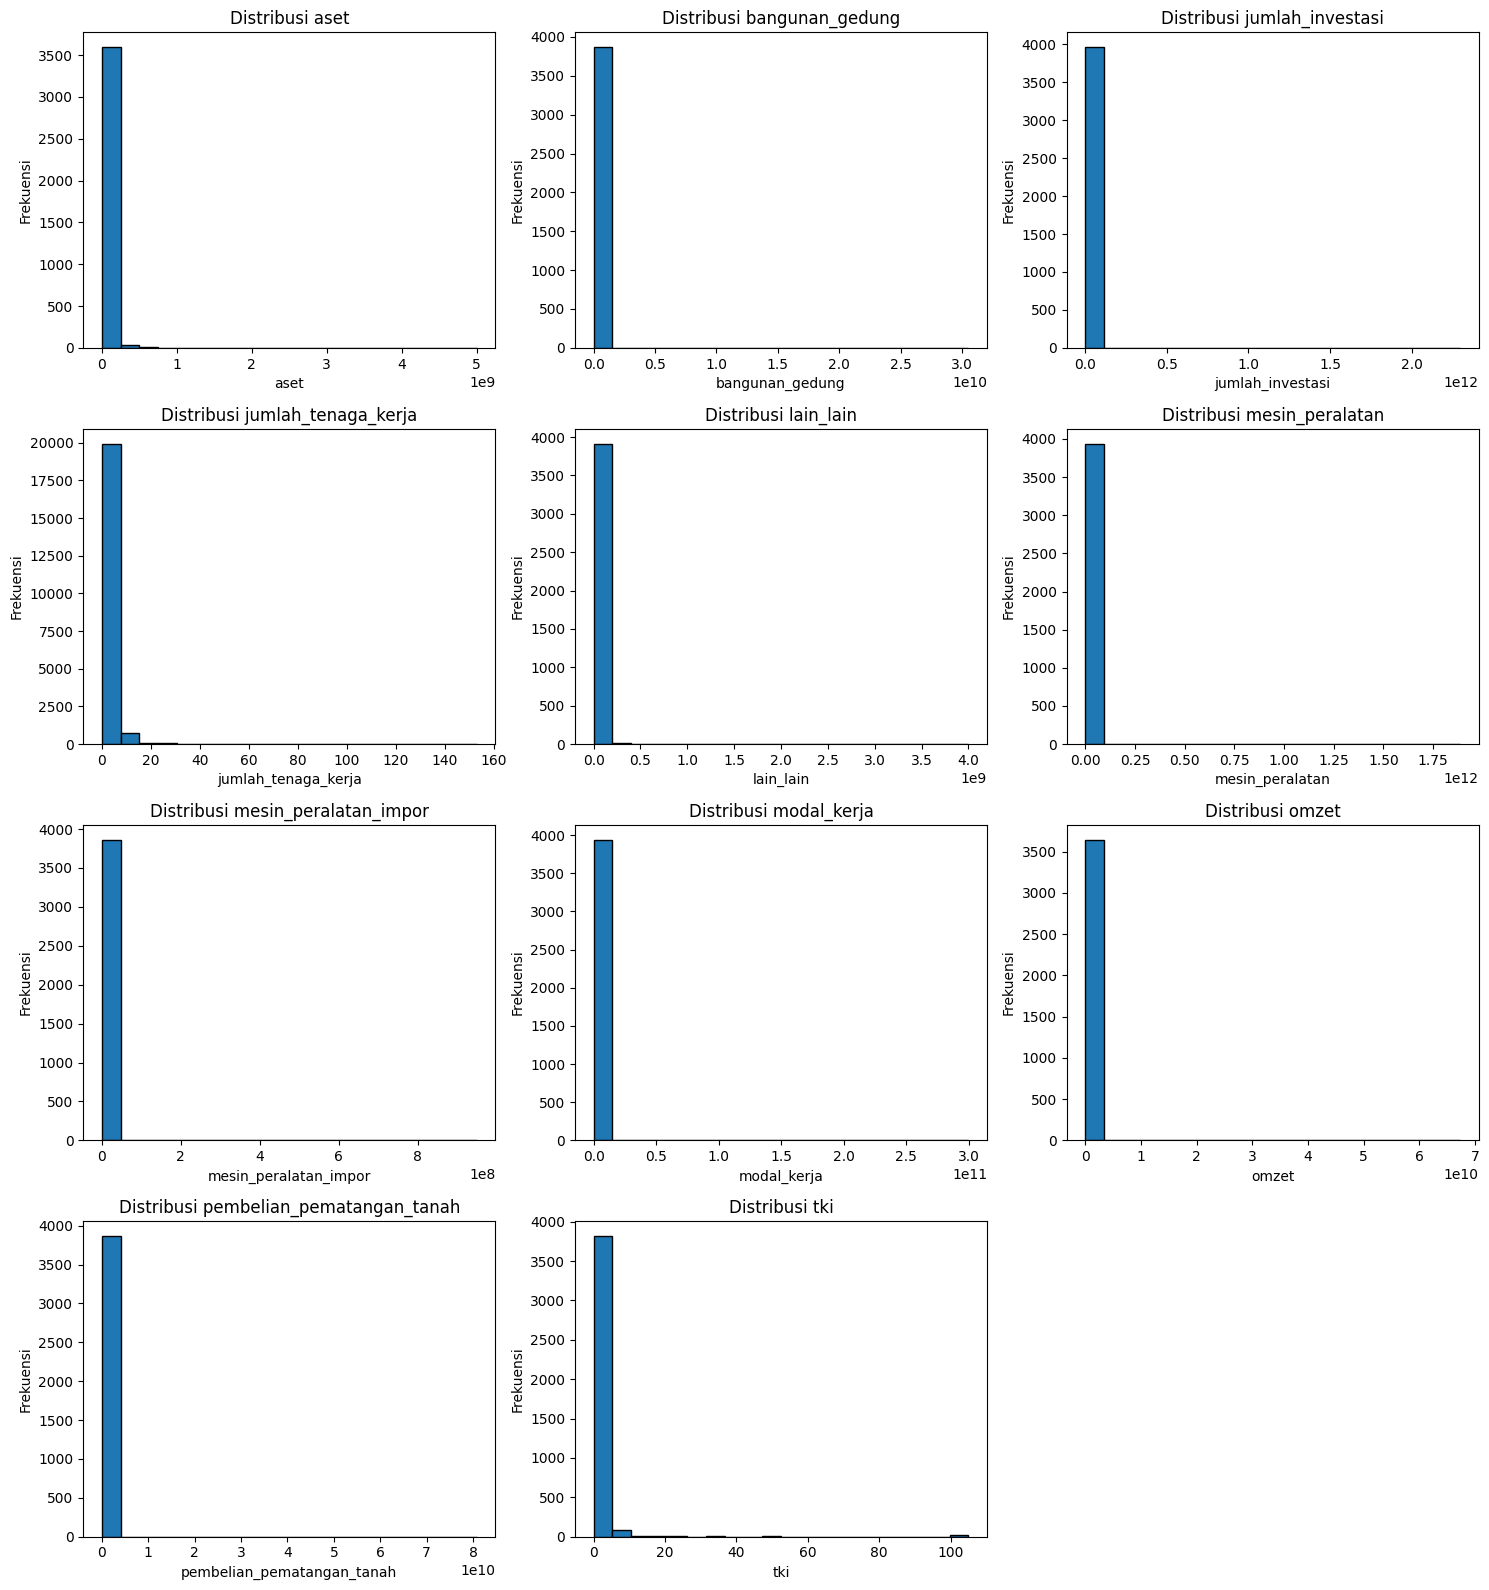

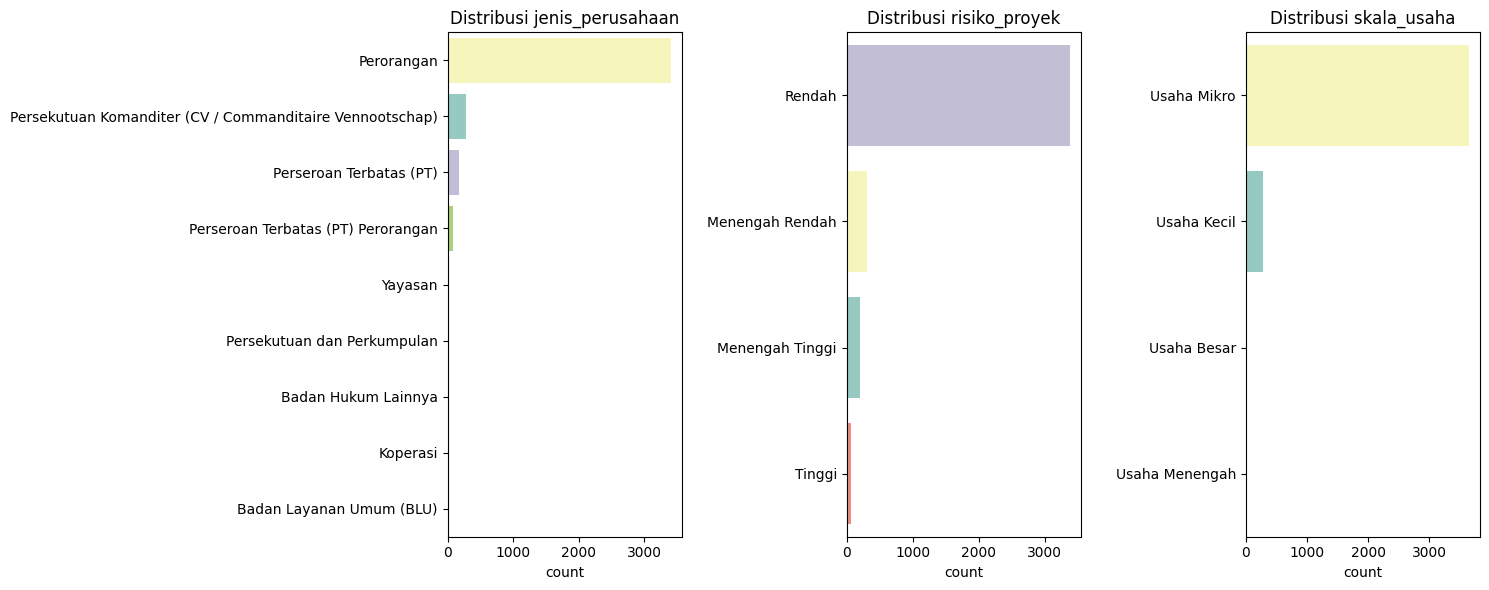

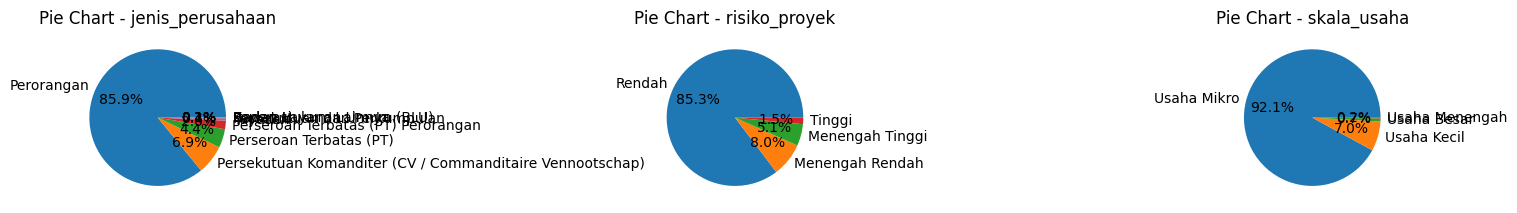

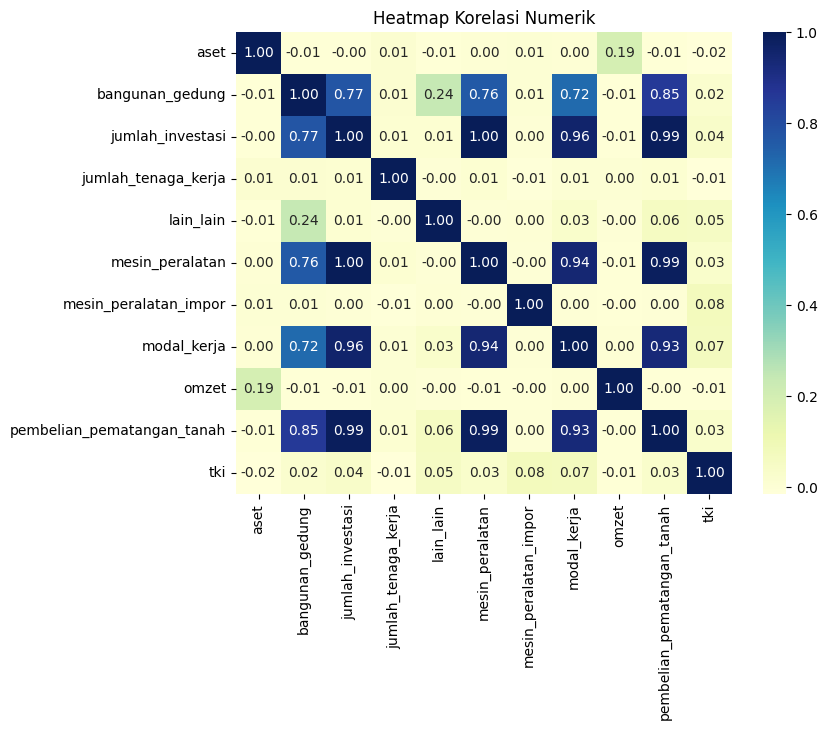

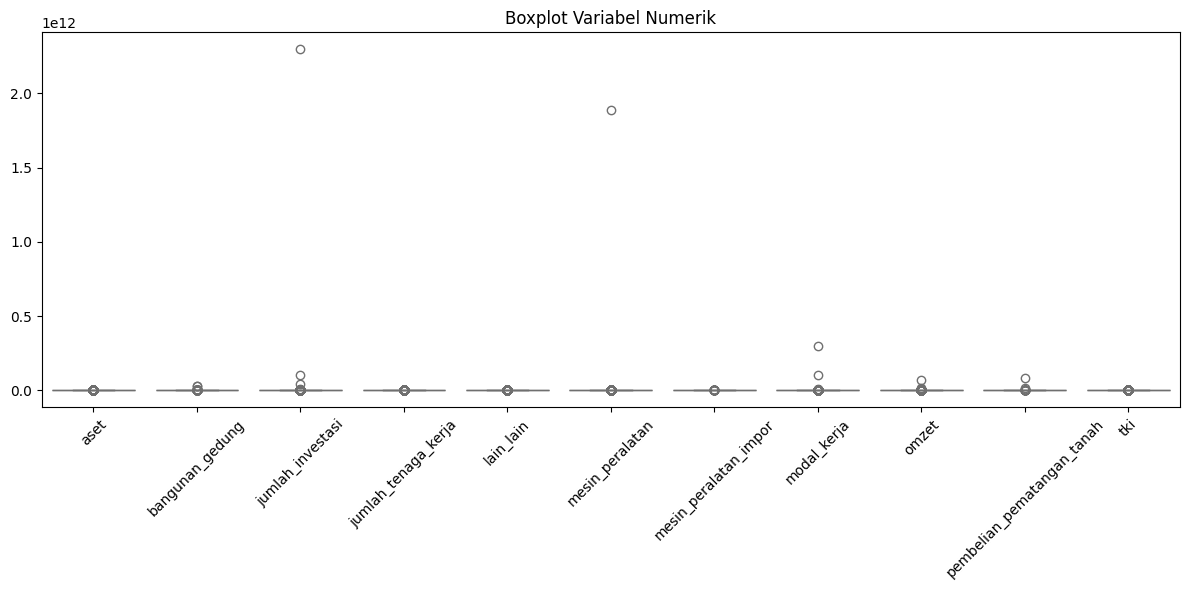


🎉 Analisis deskriptif selesai! Semua hasil disimpan ke folder 'hasil_deskriptif/'


In [ ]:
# ==========================
# PROGRAM: Analisis Deskriptif Data UMKM (Final Clean Version)
# ==========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# ============================================================
# 1. CLEANING DATA (TERMASUK KBLI & NIB)
# ============================================================

# pastikan ada kolom Nib & kbli sebelum convert
if "Nib" in df.columns:
    df["Nib"] = df["Nib"].fillna("").astype(str).str.replace(".0", "", regex=False).str.strip()

if "kbli" in df.columns:
    df["kbli"] = df["kbli"].fillna("").astype(str).str.replace(".0", "", regex=False).str.strip()


# ============================================================
# 2. CLEANING SEMUA FITUR KATEGORIKAL (Hilangkan TAB, newline, spasi ganda)
# ============================================================

def clean_text(x):
    if isinstance(x, str):
        x = x.replace("\t", " ")        # hilangkan TAB
        x = x.replace("\n", " ")        # hilangkan newline
        x = x.replace("\r", " ")
        x = ' '.join(x.split())         # rapikan spasi
        return x.strip()
    return x

df = df.applymap(clean_text)


# ============================================================
# 3. PEMISAHAN FITUR NUMERIK & KATEGORIKAL
# ============================================================

numerik = df.select_dtypes(include=["float64", "int64"])
non_numerik = df.select_dtypes(exclude=["float64", "int64"])

num_cols = numerik.columns.tolist()
cat_cols = [
    "jenis_perusahaan",
    "risiko_proyek",
    "skala_usaha",
    "status_penanaman_modal",
    "kecamatan_usaha",
    "kelurahan_usaha",
    "kl_sektor_pembina",
    "judul_kbli"
]

print("=== Kolom Numerik ===")
print(num_cols)

print("\n=== Kolom Kategorikal ===")
print(cat_cols)


# ============================================================
# 4. ANALISIS DESKRIPTIF NUMERIK
# ============================================================

desc_stats = df[num_cols].describe().T
os.makedirs("hasil_deskriptif", exist_ok=True)
desc_stats.to_csv("hasil_deskriptif/statistik_deskriptif_numerik.csv")

print("\n=== Statistik Deskriptif Numerik ===")
print(desc_stats)


# ============================================================
# 5. ANALISIS FREKUENSI KATEGORIKAL
# ============================================================

print("\n=== Frekuensi Variabel Kategorikal ===")

for col in cat_cols:
    freq = df[col].value_counts(dropna=False)
    print(f"\n{col}:\n", freq)

    fname = col.replace(" ", "_").replace("/", "_")
    freq.to_csv(f"hasil_deskriptif/frekuensi_{fname}.csv")


# ============================================================
# 6. HISTOGRAM DINAMIS UNTUK FITUR NUMERIK
# ============================================================

jumlah = len(num_cols)
cols = 3
rows = (jumlah + cols - 1) // cols

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=20, edgecolor="black")
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")

plt.tight_layout()
plt.show()


# ============================================================
# 7. COUNTPLOT KATEGORIKAL (NO WARNING)
# ============================================================

plt.figure(figsize=(15, 6))

for i, col in enumerate(cat_cols[:3], 1):
    plt.subplot(1, 3, i)

    sns.countplot(
        y=df[col],
        hue=df[col],
        order=df[col].value_counts().index,
        palette="Set3",
        legend=False
    )
    plt.title(f"Distribusi {col}")
    plt.ylabel("")

plt.tight_layout()
plt.show()


# ============================================================
# 8. PIE CHART UNTUK VARIABEL KATEGORIKAL (3 contoh)
# ============================================================

plt.figure(figsize=(15, 6))

for i, col in enumerate(cat_cols[:3], 1):
    plt.subplot(1, 3, i)
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(f"Pie Chart - {col}")
    plt.ylabel("")

plt.tight_layout()
plt.show()


# ============================================================
# 9. HEATMAP KORELASI NUMERIK
# ============================================================

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Heatmap Korelasi Numerik")
plt.show()


# ============================================================
# 10. BOXPLOT NUMERIK
# ============================================================

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], palette="pastel")
plt.title("Boxplot Variabel Numerik")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 11. OPSIONAL: ANALISIS CLUSTER JIKA ADA
# ============================================================

if "Cluster_KMeans" in df.columns:

    cluster_summary = df.groupby("Cluster_KMeans")[num_cols].mean()
    print("\n=== Rata-rata Variabel Numerik per Cluster ===")
    print(cluster_summary)

    sns.heatmap(cluster_summary, annot=True, cmap="YlOrBr", fmt=".2f")
    plt.title("Rata-rata per Cluster")
    plt.show()

    cluster_summary.to_csv("hasil_deskriptif/rata_rata_per_cluster.csv")


print("\n🎉 Analisis deskriptif selesai! Semua hasil disimpan ke folder 'hasil_deskriptif/'")


In [ ]:
!pip install pyclustering gower

# ============================================================
# 1. Import Library
# ============================================================

import pandas as pd
import numpy as np
import gower
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.metrics import silhouette_score

# ============================================================
# 2. Load Data
# ============================================================

# df = pd.read_csv("data.csv")   # <-- sesuaikan
df = df.copy()

# ============================================================
# 3. Tentukan fitur numerik & kategorikal
# ============================================================

num_features = [
    'aset', 'bangunan_gedung', 'jumlah_investasi', 'jumlah_tenaga_kerja',
    'lain_lain', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja',
    'omzet', 'pembelian_pematangan_tanah', 'tki'
]

cat_features = [
    'jenis_perusahaan', 'risiko_proyek', 'skala_usaha',
    'status_penanaman_modal', 'kecamatan_usaha', 'kelurahan_usaha',
    'kl_sektor_pembina', 'judul_kbli'
]

# ============================================================
# 4. Cleaning numerik – hapus baris yang berisi string/invalid
# ============================================================

df_clean = df.copy()

for col in num_features:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.dropna(subset=num_features)

print("Ukuran data setelah cleaning:", df_clean.shape)

# ============================================================
# 5. Handling missing kategori (isi NA dengan 'Unknown')
# ============================================================

for col in cat_features:
    df_clean[col] = df_clean[col].fillna("Unknown").astype(str)

# ============================================================
# 6. Siapkan data untuk Gower
# ============================================================

df_mixed = df_clean[num_features + cat_features]

# ============================================================
# 3. SIMPAN SEBAGAI EXCEL
# ============================================================

excel_path = "df_mixed.xlsx"
df_mixed.to_excel(excel_path, index=False)
print(f"File Excel berhasil disimpan: {excel_path}")

# ============================================================
# 7. Hitung Gower Distance Matrix
# ============================================================

print("Menghitung Gower distance...")
gower_matrix = gower.gower_matrix(df_mixed)

# ============================================================
# 8. Cari BEST K (2–7)
# ============================================================

def run_kmedoids(gower_dist, k):
    np.random.seed(42)
    initial_medoids = list(np.random.choice(len(gower_dist), k, replace=False))

    pam = kmedoids(gower_dist, initial_medoids, data_type='distance_matrix')
    pam.process()
    clusters = pam.get_clusters()

    labels = np.zeros(len(gower_dist))
    for i, c in enumerate(clusters):
        labels[c] = i

    sil = silhouette_score(gower_dist, labels, metric="precomputed")
    return sil, labels, clusters

silhouette_results = {}

print("\nMencari best k...\n")
for k in range(2, 8):
    sil, _, _ = run_kmedoids(gower_matrix, k)
    silhouette_results[k] = sil
    print(f"k={k} → Silhouette = {sil:.4f}")

best_k = max(silhouette_results, key=silhouette_results.get)

print("\n============================================")
print(f"Best k = {best_k} dengan Silhouette = {silhouette_results[best_k]:.4f}")
print("============================================")

# ============================================================
# 9. Final clustering untuk best k
# ============================================================

sil, labels, clusters = run_kmedoids(gower_matrix, best_k)
df_clean["cluster"] = labels

print("\nDistribusi tiap klaster:")
print(df_clean["cluster"].value_counts())


Ukuran data setelah cleaning: (3561, 28)
File Excel berhasil disimpan: df_mixed.xlsx
Menghitung Gower distance...

Mencari best k...

k=2 → Silhouette = 0.1338
k=3 → Silhouette = 0.1604
k=4 → Silhouette = 0.0620
k=5 → Silhouette = 0.0675
k=6 → Silhouette = 0.0717
k=7 → Silhouette = 0.0923

Best k = 3 dengan Silhouette = 0.1604

Distribusi tiap klaster:
cluster
2.0    2096
0.0     757
1.0     708
Name: count, dtype: int64


In [ ]:
# --- 1. Tentukan fitur numerik & kategorikal ---
num_features = num_cols
cat_features = cat_cols
df_selected = df_mixed

print("Fitur numerik :", num_features)
print("Fitur kategorikal :", cat_features)

# --- Hapus baris yang mengandung string pada kolom numerik ---
for col in num_features:
    df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

# Buang baris yang jadi NaN karena salah format (misal: "KIOS PASAR...")
df_selected = df_selected.dropna(subset=num_features).reset_index(drop=True)

print("Baris yang mengandung string pada kolom numerik telah dihapus.")
print("Ukuran data sekarang:", df_selected.shape)
# ========= 3. Preprocessing =========

# Konversi numerik → float
for col in num_features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Copy dataframe untuk preprocessing
df_selected = df[num_features + cat_features].copy()

# Isi missing numerik dengan median
df_selected[num_features] = df_selected[num_features].fillna(df_selected[num_features].median())

# Hilangkan duplikat
df_selected = df_selected.drop_duplicates().reset_index(drop=True)


# ========= 4. One-hot encoding + scaling =========

from sklearn.preprocessing import StandardScaler

# One-hot encoding untuk kategori
df_onehot = pd.get_dummies(df_selected, columns=cat_features, drop_first=True)

# Scaling untuk seluruh kolom numerik + hasil one-hot
scaler = StandardScaler()
X_numhot_scaled = scaler.fit_transform(df_onehot)

print("Preprocessing selesai!")
print("Shape data setelah one-hot + scaling:", X_numhot_scaled.shape)

Fitur numerik : ['aset', 'bangunan_gedung', 'jumlah_investasi', 'jumlah_tenaga_kerja', 'lain_lain', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja', 'omzet', 'pembelian_pematangan_tanah', 'tki']
Fitur kategorikal : ['jenis_perusahaan', 'risiko_proyek', 'skala_usaha', 'status_penanaman_modal', 'kecamatan_usaha', 'kelurahan_usaha', 'kl_sektor_pembina', 'judul_kbli']
Baris yang mengandung string pada kolom numerik telah dihapus.
Ukuran data sekarang: (3561, 19)
Preprocessing selesai!
Shape data setelah one-hot + scaling: (3989, 764)


In [ ]:
# (B) Mixed data (untuk K-Prototypes, tanpa one-hot)
X_mixed = df_selected.copy()
for c in cat_features:
    X_mixed[c] = X_mixed[c].astype(str)
X_mixed_values = X_mixed.values
cat_idx = [X_mixed.columns.get_loc(c) for c in cat_features]

In [ ]:
# --------- 6. Feature selection (opsional) ---------
selector = VarianceThreshold(threshold=0.01)
X_fs = selector.fit_transform(X_numhot_scaled)

# Reduksi dimensi untuk metrik & visualisasi
svd = TruncatedSVD(n_components=min(20, X_fs.shape[1]), random_state=42)
X_svd = svd.fit_transform(X_fs)


Jumlah fitur awal: 764
Jumlah fitur setelah seleksi: 764


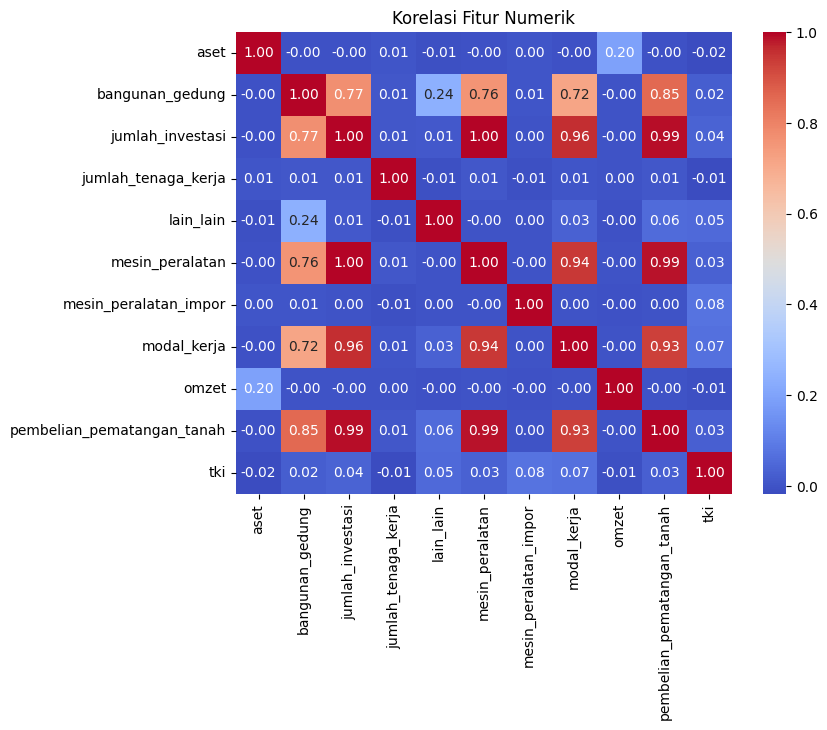

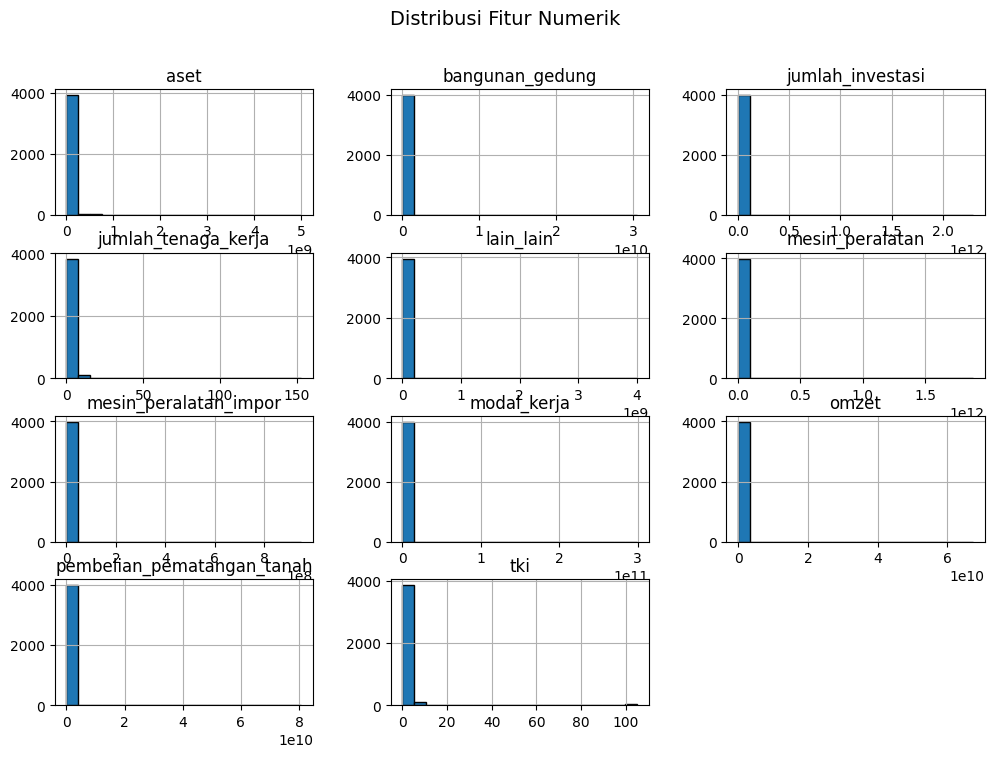

In [ ]:
# --------- 6b. Visualisasi hasil feature selection ---------

# Ambil nama fitur yang lolos seleksi
selected_features = df_onehot.columns[selector.get_support()]
print("Jumlah fitur awal:", X_numhot_scaled.shape[1])
print("Jumlah fitur setelah seleksi:", X_fs.shape[1])

# 1. Heatmap korelasi antar fitur numerik (yang asli saja)
plt.figure(figsize=(8,6))
corr = df_selected[num_features].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Korelasi Fitur Numerik")
plt.show()

# 2. Distribusi fitur numerik
df_selected[num_features].hist(bins=20, figsize=(12,8), edgecolor="black")
plt.suptitle("Distribusi Fitur Numerik", fontsize=14)
plt.show()


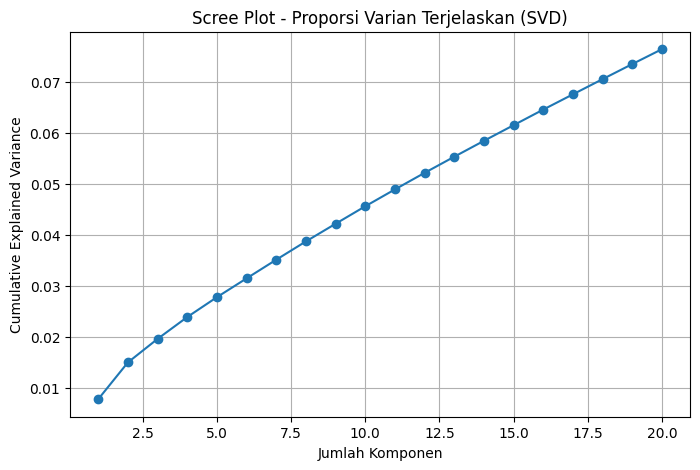

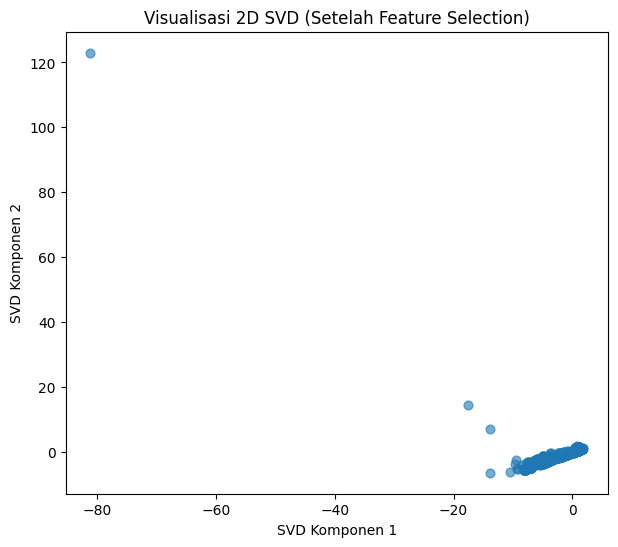

In [ ]:
# --------- 6c. Visualisasi hasil Feature Selection + SVD ---------

# 1. Scree Plot (varian per komponen)
explained_var = svd.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var.cumsum(), marker='o')
plt.title("Scree Plot - Proporsi Varian Terjelaskan (SVD)")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# 2. Scatterplot 2D SVD (komponen 1 vs 2)
plt.figure(figsize=(7,6))
plt.scatter(X_svd[:,0], X_svd[:,1], alpha=0.6, s=40)
plt.title("Visualisasi 2D SVD (Setelah Feature Selection)")
plt.xlabel("SVD Komponen 1")
plt.ylabel("SVD Komponen 2")
plt.show()


In [ ]:
# --------- 7. Fungsi hitung jarak Gower ---------
def gower_matrix(df_num, df_cat):
    """
    Hitung matriks jarak Gower untuk data numerik+kategori
    """
    n = df_num.shape[0]
    # Normalisasi numerik ke [0,1]
    num = df_num.to_numpy().astype(float)
    min_ = np.nanmin(num, axis=0)
    max_ = np.nanmax(num, axis=0)
    range_ = np.where(max_ - min_ == 0, 1, max_ - min_)
    num_norm = (num - min_) / range_

    # Kategori jadi kode integer
    cat = df_cat.astype(str)
    cat_codes = np.array([cat[col].astype('category').cat.codes.to_numpy() for col in cat.columns]).T

    # Jarak numerik (Manhattan / jumlah abs)
    diff_num = np.abs(num_norm[:, None, :] - num_norm[None, :, :])
    num_part = diff_num.mean(axis=2) if num_norm.shape[1] > 0 else np.zeros((n,n))

    # Jarak kategori (0=sama, 1=beda)
    if cat_codes.shape[1] > 0:
        cat_neq = (cat_codes[:, None, :] != cat_codes[None, :, :]).astype(float)
        cat_part = cat_neq.mean(axis=2)
    else:
        cat_part = np.zeros((n,n))

    # Kombinasikan (berat seimbang)
    w_num, w_cat = df_num.shape[1], df_cat.shape[1]
    gower_dist = (w_num * num_part + w_cat * cat_part) / (w_num + w_cat)
    return gower_dist

df_num = df_selected[num_features].reset_index(drop=True)
df_cat = df_selected[cat_features].reset_index(drop=True)
print("Hitung matriks Gower...")
gower_dist = gower_matrix(df_num, df_cat)

Hitung matriks Gower...


In [ ]:
# --------- 9. Jalankan semua metode clustering ---------

labels_store = {}

# (a) KMeans
labels_store["KMeans"] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_fs)

# (b) Fuzzy C-Means
X_for_fcm = X_fs.T
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(X_for_fcm, c=best_k, m=2, error=0.005, maxiter=1000)
labels_store["FCM"] = np.argmax(u, axis=0)

# (c) Gaussian Mixture
labels_store["GMM"] = GaussianMixture(n_components=best_k, random_state=42).fit_predict(X_svd)

# (d) DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5).fit(X_svd)
labels_store["DBSCAN"] = dbscan.labels_

# (e) K-Prototypes
kproto = KPrototypes(n_clusters=best_k, init="Huang", random_state=42, n_init=5)
labels_store["KPrototypes"] = kproto.fit_predict(X_mixed_values, categorical=cat_idx)

In [ ]:
# --------- 10. Evaluasi semua metode ---------
results = []
for name, labs in labels_store.items():
    unique_labels = set(labs)
    # Silhouette pakai Gower
    if len(unique_labels) > 1 and not (len(unique_labels)==2 and -1 in unique_labels):
        try:
            sil = silhouette_score(gower_dist, labs, metric="precomputed")
        except:
            sil = np.nan
    else:
        sil = np.nan
    # CH & DBI pakai SVD (tanpa noise -1)
    labs_np = np.array(labs)
    mask = labs_np != -1
    if mask.sum()>1 and len(set(labs_np[mask]))>1:
        ch = calinski_harabasz_score(X_svd[mask], labs_np[mask])
        dbi = davies_bouldin_score(X_svd[mask], labs_np[mask])
    else:
        ch, dbi = np.nan, np.nan
    results.append({
        "Model": name,
        "Clusters": len(set(labs)) - (1 if -1 in set(labs) else 0),
        "Silhouette_Gower": sil,
        "CH_onSVD": ch,
        "DBI_onSVD": dbi,
        "FPC": fpc if name=="FCM" else None
    })

df_results = pd.DataFrame(results).set_index("Model").sort_values("Silhouette_Gower", ascending=False)
print("\n=== Perbandingan Metode ===")
print(df_results.round(4))

best_model = df_results["Silhouette_Gower"].idxmax()
print("\nMetode terbaik:", best_model)


=== Perbandingan Metode ===
             Clusters  Silhouette_Gower  CH_onSVD  DBI_onSVD     FPC
Model                                                               
KPrototypes         3            0.5134  210.0498     0.2038     NaN
GMM                 3            0.1957  221.8068     2.5332     NaN
KMeans              3            0.0013   19.4488     0.6933     NaN
DBSCAN             79           -0.0047  201.0954     0.6702     NaN
FCM                 3           -0.0211  133.5580     3.3204  0.3333

Metode terbaik: KPrototypes


/tmp/ipython-input-546730439.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


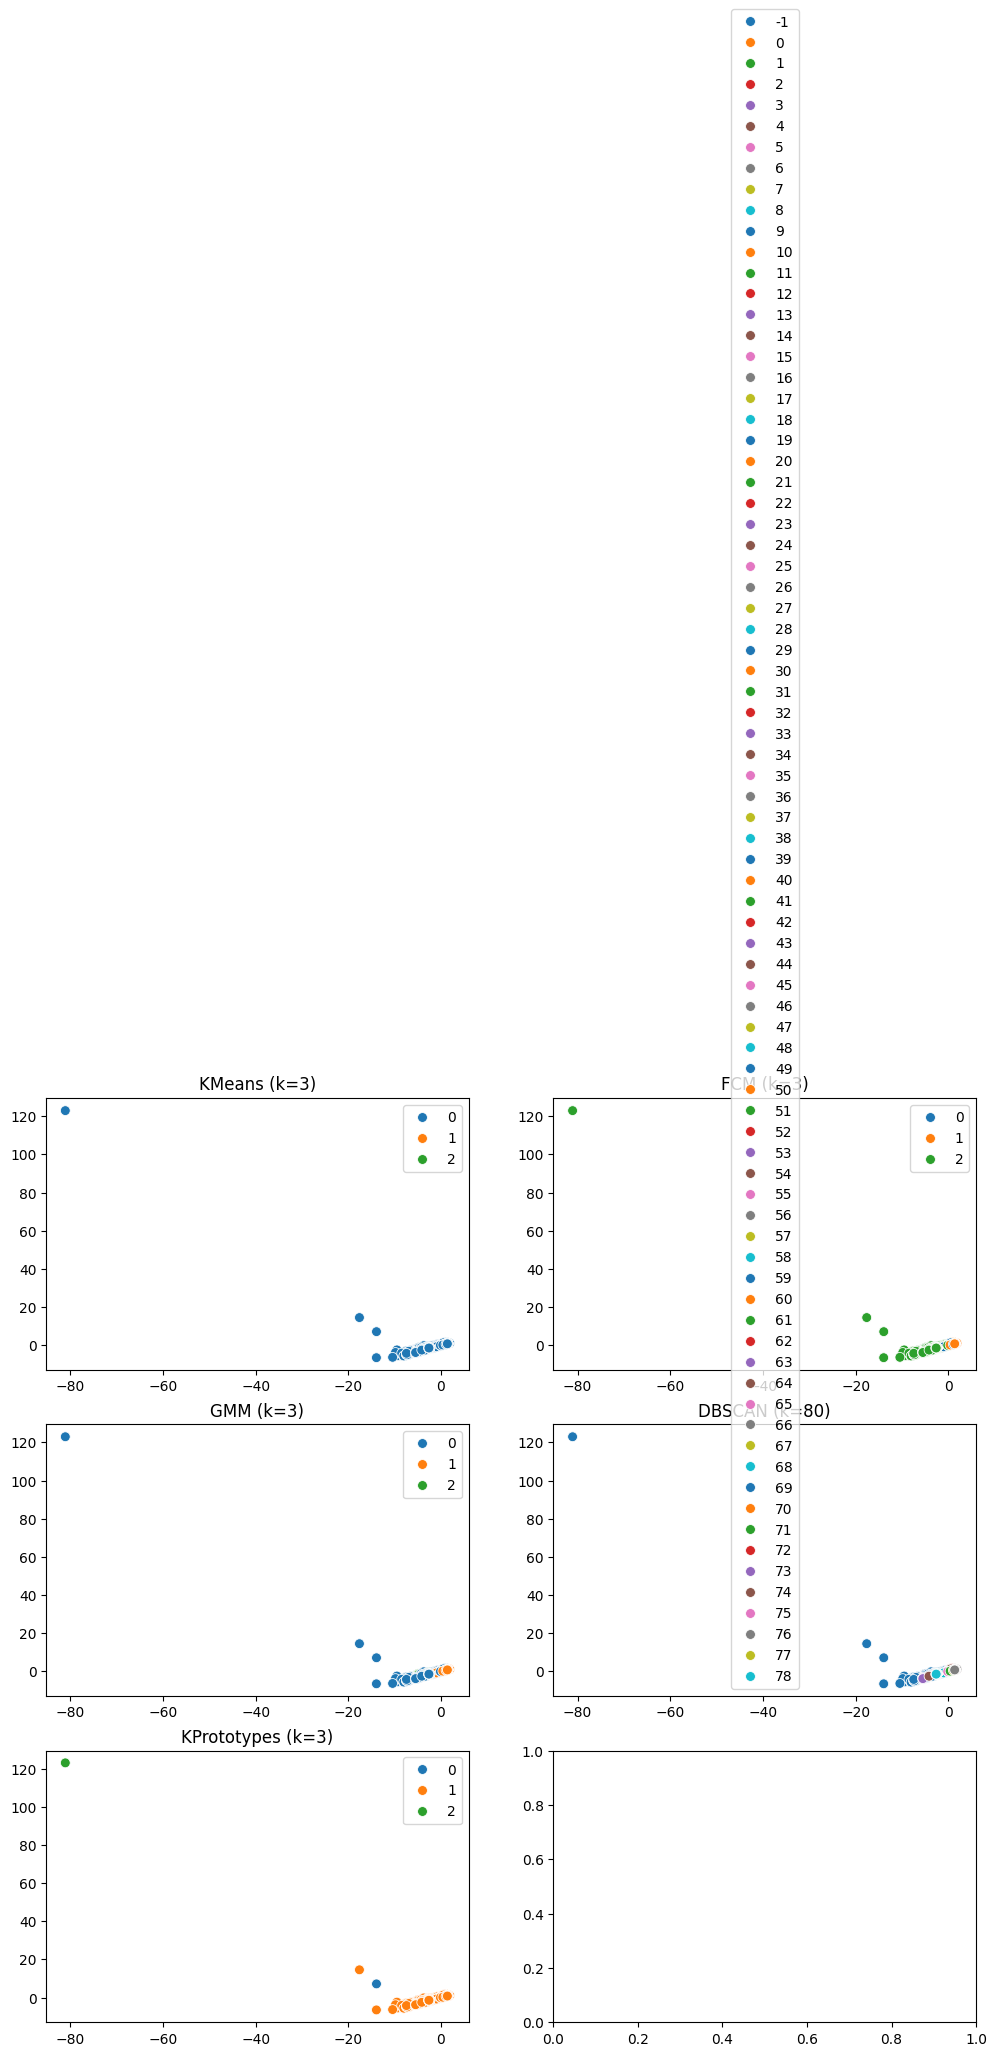

In [ ]:
# --------- 11. Visualisasi PCA 2D ---------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_fs)

fig, axes = plt.subplots(len(labels_store)//2+1, 2, figsize=(12,12))
axes = axes.flatten()
for i,(name,labs) in enumerate(labels_store.items()):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labs, palette="tab10", s=50, ax=axes[i], legend="full")
    axes[i].set_title(f"{name} (k={len(set(labs))})")
plt.tight_layout()
plt.show()

optimasi

In [ ]:
# ====== Install dependencies (Colab) ======
!pip install pyclustering gower kmodes scikit-fuzzy --quiet

# ====== Imports ======
import numpy as np
import pandas as pd
import gower
from pyclustering.cluster.kmedoids import kmedoids
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import skfuzzy as fuzz
from kmodes.kprototypes import KPrototypes
import warnings
warnings.filterwarnings("ignore")

# ====== ASSUMPTION: df_clean exists (result setelah cleaning/outlier/grouping) ======
# If not, replace the next line with your df_clean creation
# df_clean = df_selected.copy()   # or df_clean from previous steps
print("Data shape (df_clean):", df_clean.shape)

# ====== 1) Reconfirm features (adjust if needed) ======
num_features = [c for c in [
    'aset','bangunan_gedung','jumlah_investasi','jumlah_tenaga_kerja',
    'lain_lain','mesin_peralatan','mesin_peralatan_impor','modal_kerja',
    'omzet','pembelian_pematangan_tanah','tki'
] if c in df_clean.columns]

cat_features = [c for c in [
    'jenis_perusahaan','risiko_proyek','skala_usaha','status_penanaman_modal'
] if c in df_clean.columns]

print("Numeric:", num_features)
print("Categorical:", cat_features)

# ====== 2) Prepare numeric matrix (scaled) ======
scaler = RobustScaler()
X_num = scaler.fit_transform(df_clean[num_features].astype(float).fillna(0))

# ====== 3) One-hot categorical and reduce dimensionality (SVD) ======
df_cat = df_clean[cat_features].astype(str).fillna("Unknown")
df_onehot = pd.get_dummies(df_cat, drop_first=True)
# reduce dimensionality of high-dim onehot
n_svd = min(20, max(2, df_onehot.shape[1]//10))   # heuristic: up to 20 comps
svd = TruncatedSVD(n_components=n_svd, random_state=42)
X_onehot_svd = svd.fit_transform(df_onehot)

# ====== 4) Combined feature space for non-mixed methods ======
# Use numerics + SVD(onehot) for KMeans/GMM/FCM/DBSCAN
X_fs = np.hstack([X_num, X_onehot_svd])
X_svd = X_fs.copy()   # alias used previously

# ====== 5) Prepare mixed values array for KPrototypes (original categorical strings included) ======
# KPrototypes expects a numpy array where categorical columns are strings
X_mixed_df = pd.concat([df_clean[num_features], df_cat], axis=1)
# Convert numeric cols to numeric, categorical remain strings
X_mixed_values = X_mixed_df.values
# cat_idx: positions of categorical columns in X_mixed_values
cat_idx = [i for i, col in enumerate(X_mixed_df.columns) if col in cat_features]

# ====== 6) Gower distance for mixed evaluation (for KPrototypes silhouette) ======
print("Computing Gower distance (this can take time/memory)...")
gower_matrix = gower.gower_matrix(X_mixed_df)  # uses pandas DataFrame

# ====== 7) Helper: PAM wrapper for gower (if needed) ======
def pam_gower_labels(gower_dist, k, random_state=42):
    np.random.seed(random_state)
    init = list(np.random.choice(len(gower_dist), k, replace=False))
    pam = kmedoids(gower_dist, init, data_type='distance_matrix')
    pam.process()
    clusters = pam.get_clusters()
    labels = np.zeros(len(gower_dist), dtype=int)
    for i, c in enumerate(clusters):
        labels[c] = i
    return labels

# ====== 8) Grid-search for K-Prototypes' gamma and init (use silhouette with Gower) ======
best_kproto = {"sil": -999, "gamma": None, "init": None, "labels": None}
gammas = [0.1, 0.5, 1, 2, 5]
inits = ["Huang", "Cao"]
k_target = 3  # you want 3 clusters

for g in gammas:
    for init_method in inits:
        try:
            kp = KPrototypes(n_clusters=k_target, init=init_method, gamma=g, n_init=5, verbose=0)
            labels_kp = kp.fit_predict(X_mixed_values, categorical=cat_idx)
            # silhouette using precomputed Gower
            sil = silhouette_score(gower_matrix, labels_kp, metric="precomputed")
            if sil > best_kproto["sil"]:
                best_kproto.update({"sil": sil, "gamma": g, "init": init_method, "labels": labels_kp})
            print(f"KPrototypes gamma={g}, init={init_method} -> Silhouette(Gower)={sil:.4f}")
        except Exception as e:
            print("KPrototypes failed for gamma", g, init_method, e)

print("Best KPrototypes:", best_kproto["gamma"], best_kproto["init"], "sil=", best_kproto["sil"])

# ====== 9) Run other methods (KMeans, GMM, FCM, DBSCAN) on X_fs / X_svd ======
labels_store = {}
metrics = {}

# (a) KMeans
kmeans = KMeans(n_clusters=k_target, random_state=42, n_init=50)
labels_store["KMeans"] = kmeans.fit_predict(X_fs)

# (b) FCM (fuzzy c-means) - uses transposed matrix
cntr, u, _, _, _, _, fpc = fuzz.cluster.cmeans(X_fs.T, c=k_target, m=2, error=0.005, maxiter=1000)
labels_store["FCM"] = np.argmax(u, axis=0)
metrics["FCM_fpc"] = fpc

# (c) GMM
gmm = GaussianMixture(n_components=k_target, random_state=42, n_init=10)
labels_store["GMM"] = gmm.fit_predict(X_svd)

# (d) DBSCAN - can produce variable cluster count; use eps heuristic or tuned value
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_store["DBSCAN"] = dbscan.fit_predict(X_svd)

# (e) KPrototypes (best params from grid-search)
labels_store["KPrototypes"] = best_kproto["labels"]

# ====== 10) Evaluate each method ======
results = []
for model_name, labels in labels_store.items():
    # If DBSCAN labels may include -1 -> treat as noise; silhouette requires at least 2 clusters
    unique_labels = set(labels)
    n_clusters = len([lab for lab in unique_labels if lab != -1])

    # Choose appropriate representation & metric for silhouette:
    if model_name == "KPrototypes":
        # silhouette on Gower (precomputed)
        sil = silhouette_score(gower_matrix, labels, metric="precomputed")
        # CH & DBI computed on SVD feature space (approx)
        try:
            ch = calinski_harabasz_score(X_svd, labels)
            dbi = davies_bouldin_score(X_svd, labels)
        except:
            ch = np.nan; dbi = np.nan
    else:
        # use Euclidean silhouette on X_fs
        try:
            sil = silhouette_score(X_fs, labels, metric="euclidean")
            ch = calinski_harabasz_score(X_fs, labels)
            dbi = davies_bouldin_score(X_fs, labels)
        except:
            sil = np.nan; ch = np.nan; dbi = np.nan

    fpc_val = metrics.get(model_name + "_fpc", np.nan)
    results.append({
        "Model": model_name,
        "Clusters": n_clusters,
        "Silhouette_Gower_or_Euclid": round(float(sil), 4) if not np.isnan(sil) else np.nan,
        "CH_onSVD": round(float(ch),4) if not np.isnan(ch) else np.nan,
        "DBI_onSVD": round(float(dbi),4) if not np.isnan(dbi) else np.nan,
        "FPC": round(float(fpc_val),4) if not np.isnan(fpc_val) else np.nan
    })

df_results = pd.DataFrame(results).set_index("Model").sort_values(by="Silhouette_Gower_or_Euclid", ascending=False)
print("\n=== Perbandingan Metode ===")
print(df_results)

# ====== 11) Save results and clustered data (use best method choice if desired) ======
df_out = df_clean.copy()
# choose to attach KPrototypes cluster if available
if "KPrototypes" in labels_store:
    df_out["cluster_kprototypes"] = labels_store["KPrototypes"]
df_out.to_csv("df_cluster_comparison.csv", index=False)
print("Saved df_cluster_comparison.csv")

# ====== 12) Determine Best Model Automatically ======

df_select = df_results.copy()

# Step 1 — gunakan Silhouette sebagai metrik utama
# jika ada nilai NaN, treat sebagai -inf supaya tidak dipilih
df_select["Silhouette_rank"] = df_select["Silhouette_Gower_or_Euclid"].fillna(-9999)

# Step 2 — DBI (lebih rendah lebih baik)
df_select["DBI_rank"] = df_select["DBI_onSVD"].fillna(9999)

# Step 3 — CH (lebih tinggi lebih baik)
df_select["CH_rank"] = df_select["CH_onSVD"].fillna(-9999)

# Normalisasi ranking (tujuan: skor total, semakin besar semakin baik)
df_select["Score"] = (
    df_select["Silhouette_rank"] * 2     # Silhouette double weight (terpenting)
    + (-df_select["DBI_rank"]) * 1       # DBI dikali -1 karena lebih kecil lebih bagus
    + df_select["CH_rank"] * 0.5         # CH sebagai tie-breaker ringan
)

best_model = df_select["Score"].idxmax()

print("\n=== Model Terbaik Berdasarkan Skor Gabungan ===")
print("Best Model:", best_model)
print(df_select.loc[best_model])

Data shape (df_clean): (3561, 29)
Numeric: ['aset', 'bangunan_gedung', 'jumlah_investasi', 'jumlah_tenaga_kerja', 'lain_lain', 'mesin_peralatan', 'mesin_peralatan_impor', 'modal_kerja', 'omzet', 'pembelian_pematangan_tanah', 'tki']
Categorical: ['jenis_perusahaan', 'risiko_proyek', 'skala_usaha', 'status_penanaman_modal']
Computing Gower distance (this can take time/memory)...
KPrototypes gamma=0.1, init=Huang -> Silhouette(Gower)=0.2953
KPrototypes gamma=0.1, init=Cao -> Silhouette(Gower)=0.2953
KPrototypes gamma=0.5, init=Huang -> Silhouette(Gower)=0.2953
KPrototypes gamma=0.5, init=Cao -> Silhouette(Gower)=0.2953
KPrototypes gamma=1, init=Huang -> Silhouette(Gower)=0.2953
KPrototypes gamma=1, init=Cao -> Silhouette(Gower)=0.2953
KPrototypes gamma=2, init=Huang -> Silhouette(Gower)=0.2953
KPrototypes gamma=2, init=Cao -> Silhouette(Gower)=0.2953
KPrototypes gamma=5, init=Huang -> Silhouette(Gower)=0.2953
KPrototypes gamma=5, init=Cao -> Silhouette(Gower)=0.2953
Best KPrototypes: 0.1 

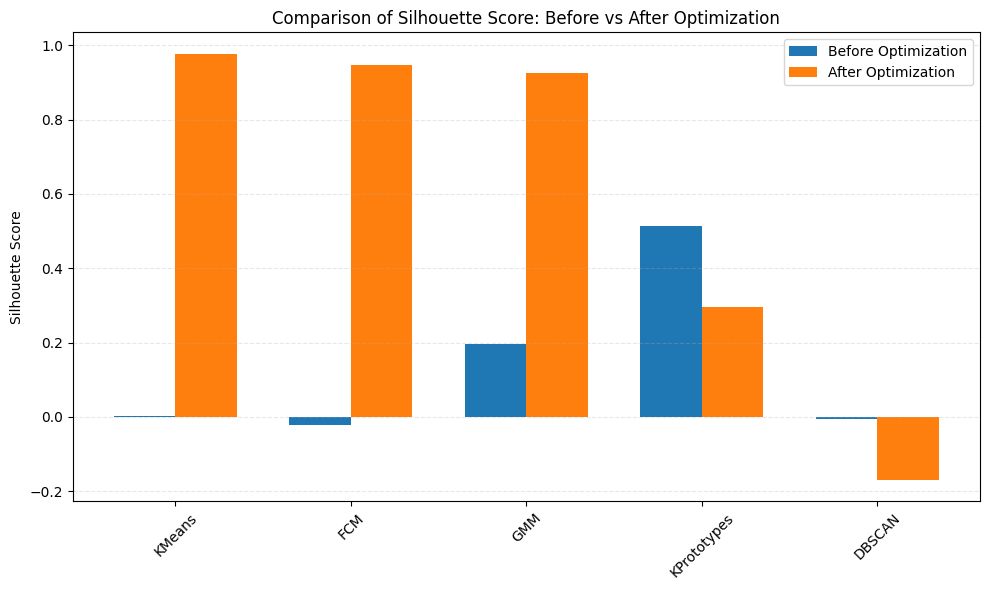

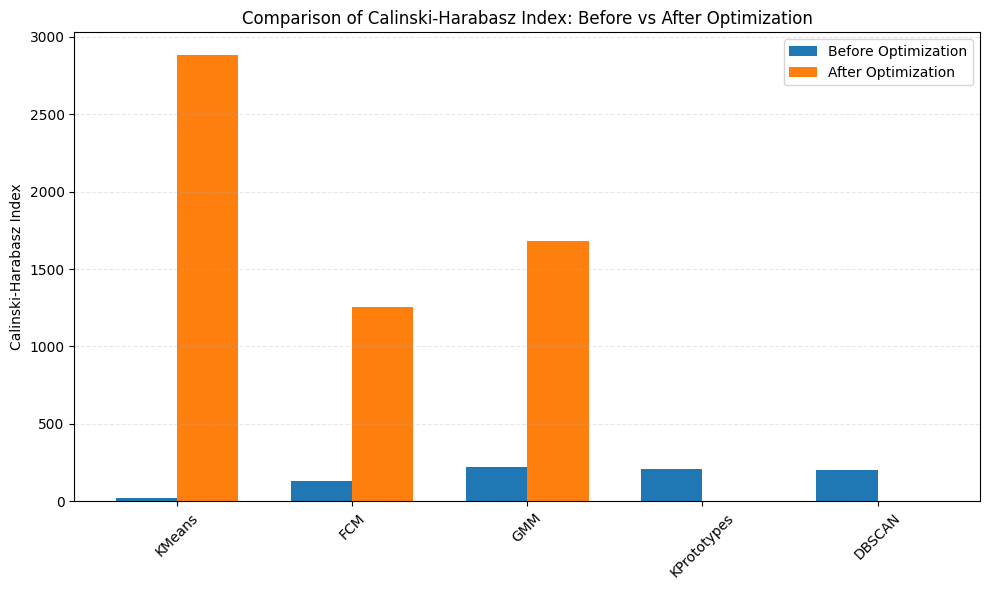

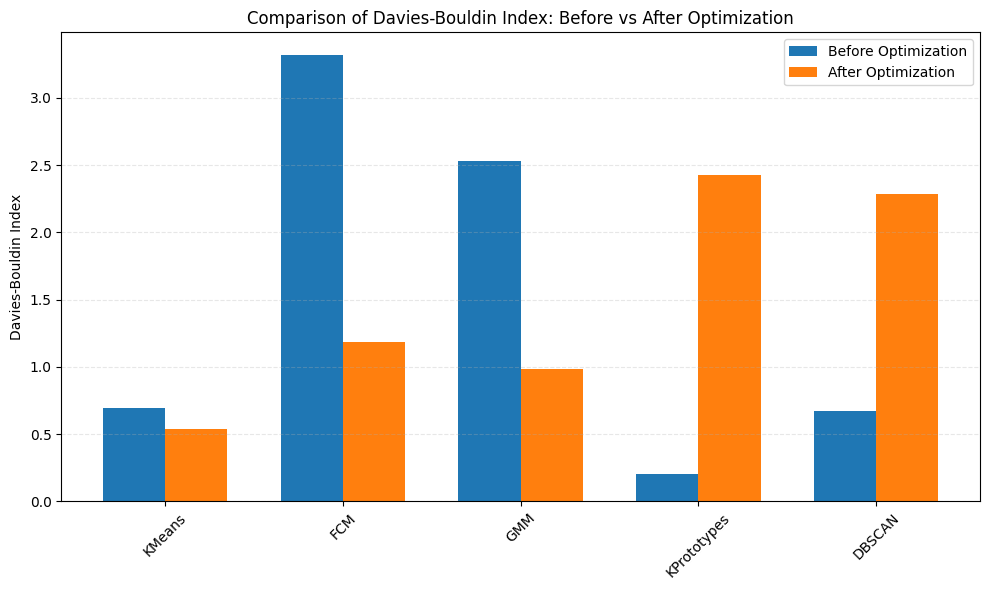

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA SEBELUM OPTIMASI
# =========================
df_before = pd.DataFrame({
    "Model": ["KPrototypes", "GMM", "KMeans", "DBSCAN", "FCM"],
    "Silhouette": [0.5134, 0.1957, 0.0013, -0.0047, -0.0211],
    "CH": [210.0498, 221.8068, 19.4488, 201.0954, 133.5580],
    "DBI": [0.2038, 2.5332, 0.6933, 0.6702, 3.3204]
})

df_before.set_index("Model", inplace=True)


# =========================
# DATA SETELAH OPTIMASI
# =========================
df_after = pd.DataFrame({
    "Model": ["KMeans", "FCM", "GMM", "KPrototypes", "DBSCAN"],
    "Silhouette": [0.9774, 0.9477, 0.9241, 0.2953, -0.1700],
    "CH": [2883.5436, 1255.1981, 1683.2375, 0.0225, 1.1538],
    "DBI": [0.5416, 1.1815, 0.9839, 2.4288, 2.2868],
})

df_after.set_index("Model", inplace=True)


# =========================
# FUNGSI UTAMA PLOTTING
# =========================
def plot_comparison(metric_name, ylabel):
    before_vals = df_before[metric_name]
    after_vals = df_after[metric_name]

    models = df_after.index  # urutan mengikuti "after"
    x = np.arange(len(models))
    width = 0.35

    plt.figure(figsize=(10,6))
    plt.bar(x - width/2, before_vals.reindex(models), width, label="Before Optimization")
    plt.bar(x + width/2, after_vals.reindex(models), width, label="After Optimization")

    plt.xticks(x, models, rotation=45)
    plt.ylabel(ylabel)
    plt.title(f"Comparison of {ylabel}: Before vs After Optimization")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


# =========================
# 1. Silhouette Comparison
# =========================
plot_comparison("Silhouette", "Silhouette Score")

# =========================
# 2. CH Comparison
# =========================
plot_comparison("CH", "Calinski-Harabasz Index")

# =========================
# 3. DBI Comparison
# =========================
plot_comparison("DBI", "Davies-Bouldin Index")



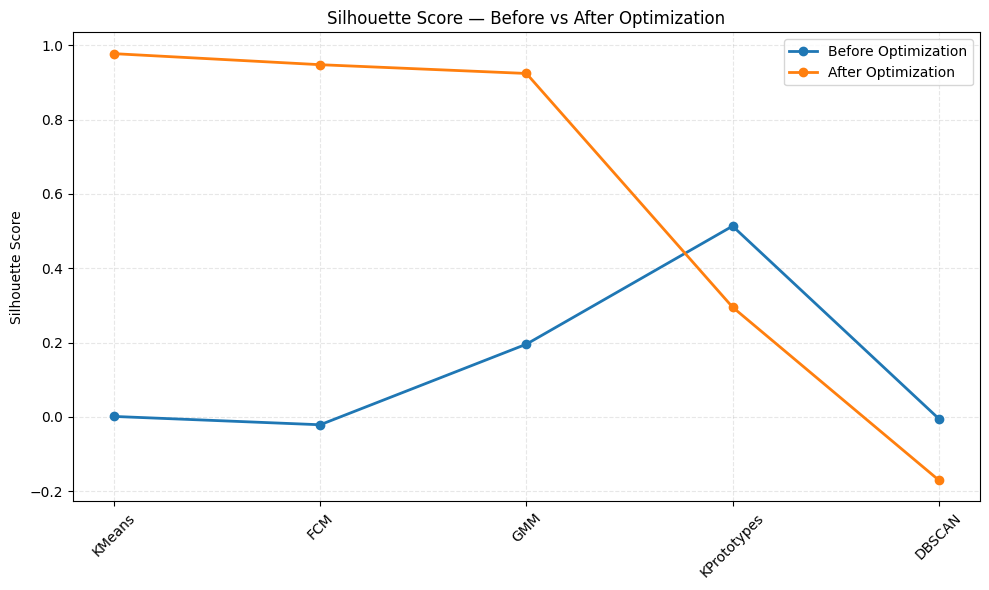

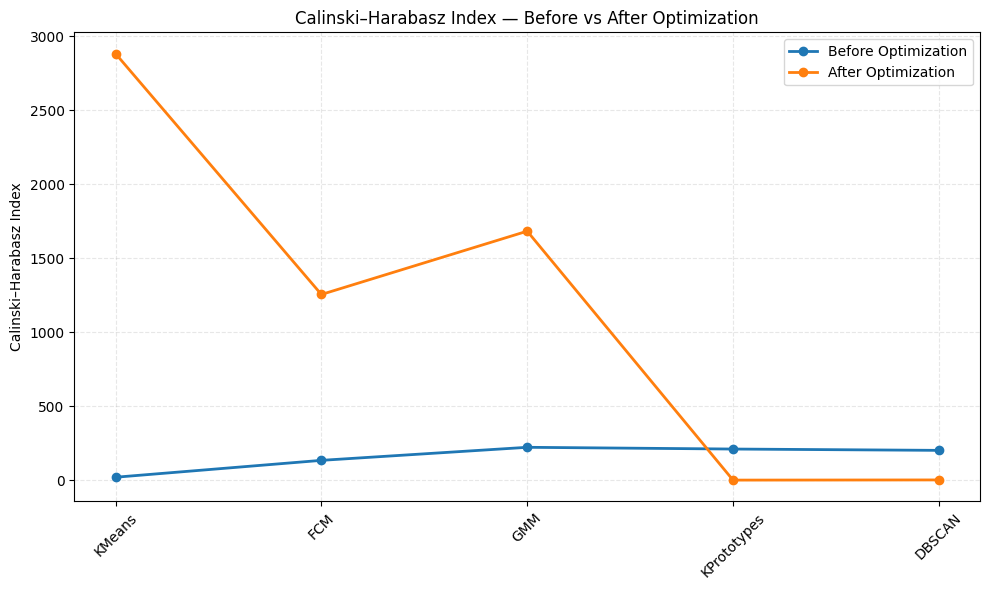

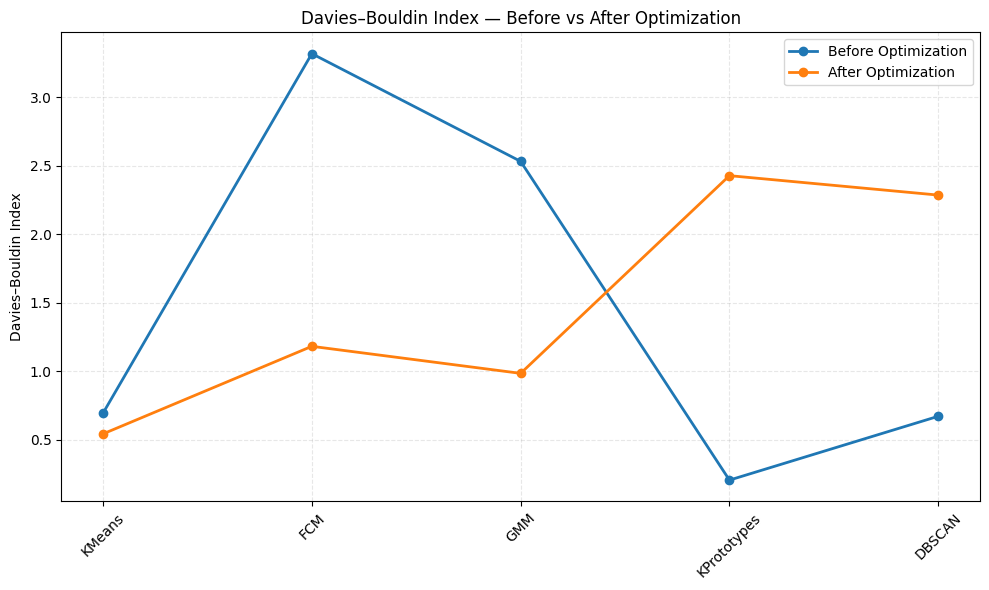

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# DATA SEBELUM OPTIMASI
# =========================
df_before = pd.DataFrame({
    "Model": ["KPrototypes", "GMM", "KMeans", "DBSCAN", "FCM"],
    "Silhouette": [0.5134, 0.1957, 0.0013, -0.0047, -0.0211],
    "CH": [210.0498, 221.8068, 19.4488, 201.0954, 133.5580],
    "DBI": [0.2038, 2.5332, 0.6933, 0.6702, 3.3204]
}).set_index("Model")

# =========================
# DATA SESUDAH OPTIMASI
# =========================
df_after = pd.DataFrame({
    "Model": ["KMeans", "FCM", "GMM", "KPrototypes", "DBSCAN"],
    "Silhouette": [0.9774, 0.9477, 0.9241, 0.2953, -0.1700],
    "CH": [2883.5436, 1255.1981, 1683.2375, 0.0225, 1.1538],
    "DBI": [0.5416, 1.1815, 0.9839, 2.4288, 2.2868]
}).set_index("Model")

# Pastikan urutan model sama pada kedua tabel
models = df_after.index

# =========================
# FUNGSI PLOT GARIS
# =========================
def plot_line(metric_name, ylabel):
    before_vals = df_before[metric_name].reindex(models)
    after_vals = df_after[metric_name].reindex(models)

    plt.figure(figsize=(10,6))

    # Garis sebelum
    plt.plot(models, before_vals, marker="o", linestyle="-", linewidth=2,
             label="Before Optimization")

    # Garis sesudah
    plt.plot(models, after_vals, marker="o", linestyle="-", linewidth=2,
             label="After Optimization")

    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} — Before vs After Optimization")
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================
# PLOT 1: Silhouette
# =========================
plot_line("Silhouette", "Silhouette Score")

# =========================
# PLOT 2: Calinski–Harabasz
# =========================
plot_line("CH", "Calinski–Harabasz Index")

# =========================
# PLOT 3: Davies–Bouldin
# =========================
plot_line("DBI", "Davies–Bouldin Index")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ====== FIX: Define df_best & labels_best based on best_model ======

model = best_model  # dari step sebelumnya

# Tentukan labels sesuai model terbaik
labels_best = labels_store[model]

# Buat salinan dataframe
df_best = df_clean.copy()

# Tambahkan kolom cluster
df_best["cluster_best"] = labels_best

print("Best model:", model)
print("Cluster counts:")
print(df_best["cluster_best"].value_counts())


# RAW data yang digunakan: df_best (sudah ada cluster_best)
labels = df_best["cluster_best"].values
n_clusters = len(np.unique(labels))

# ============================
# 1) SILHOUETTE PLOT
# ============================
from sklearn.metrics import silhouette_samples, silhouette_score

X_plot = X_fs  # dataset fitur untuk silhouette
silhouette_vals = silhouette_samples(X_plot, labels)

plt.figure(figsize=(10, 6))
y_lower = 10

for i in range(n_clusters):
    ith_vals = silhouette_vals[labels == i]
    ith_vals.sort()
    size_i = ith_vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_vals, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_i, str(i))
    y_lower = y_upper + 10

sil_avg = silhouette_score(X_plot, labels)

plt.axvline(x=sil_avg, color='red', linestyle='--')
plt.title(f"Silhouette Plot — KMeans (avg={sil_avg:.4f})")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


# ============================
# 2) CLUSTER PROFILE (MEAN PER NUMERIC FEATURE)
# ============================

cluster_profile = df_best.groupby("cluster_best")[num_features].mean()

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap="Blues")
plt.title("Cluster Profile (Mean per Numeric Feature) — KMeans")
plt.show()


# ============================
# 3) RADAR PLOT (OPTIONAL — untuk jurnal)
# ============================

import numpy as np
from math import pi

features = num_features
num_vars = len(features)

# normalisasi 0–1 supaya comparable
norm_cp = (cluster_profile - cluster_profile.min()) / \
          (cluster_profile.max() - cluster_profile.min())

angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
angles += angles[:1]

plt.figure(figsize=(8, 8))

for idx, row in norm_cp.iterrows():
    values = row.values.tolist()
    values += values[:1]
    plt.polar(angles, values, marker="o", label=f"Cluster {idx}")

plt.xticks(angles[:-1], features, fontsize=8)

plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.show()


NameError: name 'best_model' is not defined

In [ ]:
# --------- 12. Profilisasi cluster (numerik & kategori) ---------
final_labels = labels_store[best_model]
df_profile = df_selected.copy()
df_profile["Cluster"] = final_labels

# rata-rata numerik
num_profile = df_profile[df_profile["Cluster"]!=-1].groupby("Cluster")[num_features].mean()
print("\nProfil Numerik per Cluster:")
print(num_profile.round(2))

# proporsi kategori
for c in cat_features:
    tbl = pd.crosstab(df_profile["Cluster"], df_profile[c], normalize="index").round(3)
    print(f"\nProporsi {c} per cluster:")
    print(tbl.head())

# heatmap numerik
plt.figure(figsize=(8,6))
sns.heatmap(num_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Profil Rata-Rata Numerik ({best_model})")
plt.show()

# --------- 13. Export hasil ---------
# a) dataset + label cluster terbaik
df_profile.to_csv("cluster_results.csv", index=False)

# b) tabel metrik perbandingan
df_results.to_csv("clustering_metrics.csv")

ValueError: Length of values (3561) does not match length of index (3989)


Profil Numerik per Cluster:
                aset  bangunan_gedung  jumlah_investasi  jumlah_tenaga_kerja  \
Cluster                                                                        
0        32578292.78     2.651904e+05      1.279406e+07                 2.94   
1        11106821.43     1.553571e+08      4.971429e+08                 2.43   
2        71992000.00     1.000000e+08      1.070772e+09                 2.00   

            lain_lain  mesin_peralatan  mesin_peralatan_impor  modal_kerja  \
Cluster                                                                      
0        1.715049e+06     4.535825e+05           9.026798e+04    975698.17   
1        1.321429e+08     6.607143e+07           7.857143e+06  32285714.29   
2        0.000000e+00     1.500000e+08           7.507718e+08  70000000.00   

                omzet  pembelian_pematangan_tanah    tki  
Cluster                                                   
0        1.437013e+08                1.205501e+05   2.56  
1 

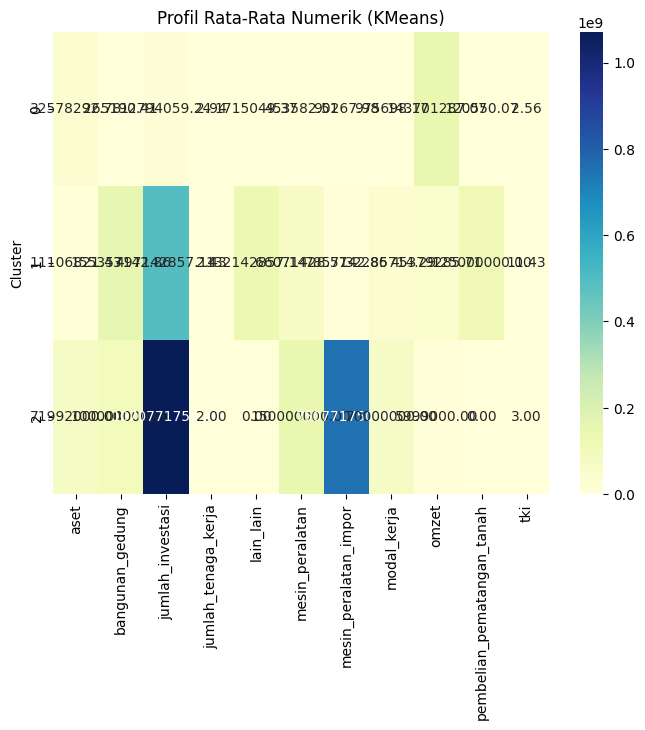

In [ ]:
# --------- 12. Profilisasi cluster (numerik & kategori) ---------

# Pastikan df_clean digunakan (3561 baris)
df_profile = df_clean.copy()
df_profile["Cluster"] = labels_store[best_model]   # aman, panjang sama

# rata-rata numerik
num_profile = df_profile[df_profile["Cluster"]!=-1].groupby("Cluster")[num_features].mean()
print("\nProfil Numerik per Cluster:")
print(num_profile.round(2))

# proporsi kategori
for c in cat_features:
    tbl = pd.crosstab(df_profile["Cluster"], df_profile[c], normalize="index").round(3)
    print(f"\nProporsi {c} per cluster:")
    print(tbl.head())

# heatmap numerik
plt.figure(figsize=(8,6))
sns.heatmap(num_profile, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Profil Rata-Rata Numerik ({best_model})")
plt.show()

# --------- 13. Export hasil ---------
df_profile.to_csv("cluster_results.csv", index=False)
df_results.to_csv("clustering_metrics.csv")


In [ ]:
from google.colab import files
files.download("cluster_results.csv")
files.download("clustering_metrics.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

hasil yang diperoleh akan dilanjutkan untuk prediksi

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cluster_results.csv to cluster_results.csv


In [ ]:
# ----------------------------
# 1. Load data
# ----------------------------
df1 = pd.read_csv("cluster_results.csv")
print("Data shape:", df1.shape)
print(df1.columns.tolist())

Data shape: (58, 12)
['Omzet', 'Aset', 'Jumlah tenaga kerja', 'Modal Kerja', 'Jumlah Investasi', 'Uraian Skala Usaha', 'kecamatan_usaha', 'Uraian Status Penanaman Modal', 'Uraian Jenis Perusahaan', 'Uraian Risiko Proyek', 'KL/Sektor Pembina', 'Cluster']


In [ ]:
# 2. Feature selection (numeric & categorical)
# ----------------------------
num_features = ["Omzet", "Aset", "Jumlah tenaga kerja", "Modal Kerja", "Jumlah Investasi"]
cat_features = [
    "Uraian Skala Usaha",
    "kecamatan_usaha",
    "Uraian Status Penanaman Modal",
    "Uraian Jenis Perusahaan",
    "Uraian Risiko Proyek",
    "KL/Sektor Pembina"
]
target_col = "Cluster"


In [ ]:
# 3. Data cleaning
# ----------------------------
df1 = df1.dropna(subset=[target_col]).reset_index(drop=True)
df1[target_col] = df1[target_col].astype(int)

for c in num_features:
    df1[c] = pd.to_numeric(df1[c], errors='coerce')

df1 = df1.dropna(subset=num_features).reset_index(drop=True)

In [ ]:
# 4. X, y preparation
# ----------------------------
X = df1[num_features + cat_features]
y = df1[target_col]

numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

In [ ]:
# 5. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
# 6. Preprocess + SMOTE
# ----------------------------
pipeline_preprocess = Pipeline([('pre', preprocessor)])
X_train_pre = pipeline_preprocess.fit_transform(X_train)
X_test_pre = pipeline_preprocess.transform(X_test)

use_smote = True
if use_smote:
    try:
        sm = SMOTE(random_state=42, k_neighbors=2)
        X_train_res, y_train_res = sm.fit_resample(X_train_pre, y_train)
    except ValueError:
        print("⚠️ SMOTE dilewati karena kelas minoritas terlalu sedikit")
        X_train_res, y_train_res = X_train_pre, y_train
else:
    X_train_res, y_train_res = X_train_pre, y_train



/tmp/ipython-input-2248159586.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette="Set2")


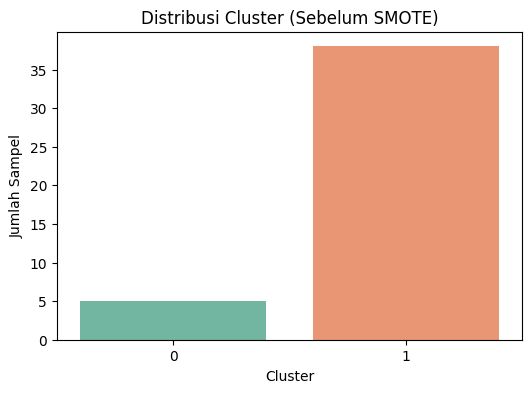

/tmp/ipython-input-2248159586.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette="Set1")


Distribusi sebelum SMOTE: Counter({1: 38, 0: 5})


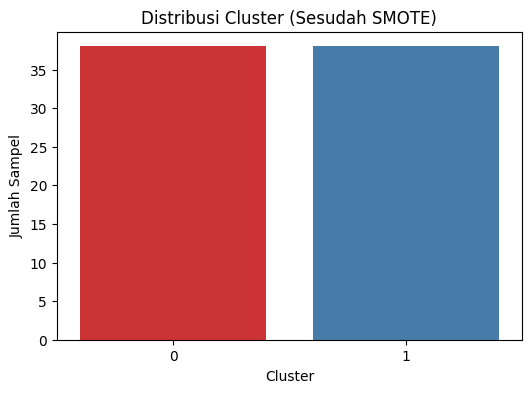

Distribusi sesudah SMOTE: Counter({1: 38, 0: 38})


In [ ]:
# Sebelum SMOTE
# ======================
plt.figure(figsize=(6,4))
sns.countplot(x=y_train, palette="Set2")
plt.title("Distribusi Cluster (Sebelum SMOTE)")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Sampel")
plt.show()

print("Distribusi sebelum SMOTE:", Counter(y_train))

# ======================
# Sesudah SMOTE
# ======================
plt.figure(figsize=(6,4))
sns.countplot(x=y_train_res, palette="Set1")
plt.title("Distribusi Cluster (Sesudah SMOTE)")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Sampel")
plt.show()

print("Distribusi sesudah SMOTE:", Counter(y_train_res))


=== Baseline RandomForest ===
Accuracy: 1.0
Balanced Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        13

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



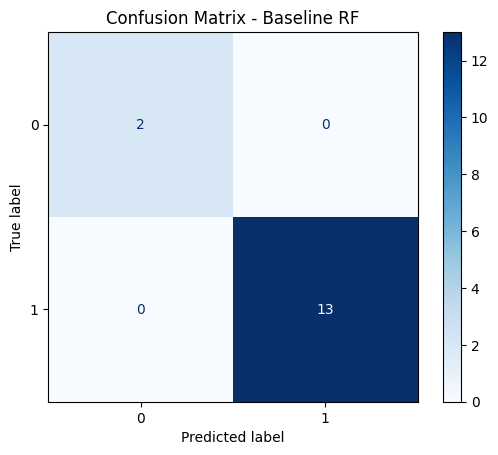

In [ ]:
# 7. Baseline RandomForest
# ----------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_pred = rf.predict(X_test_pre)

print("\n=== Baseline RandomForest ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Baseline RF")
plt.show()

baseline_acc = accuracy_score(y_test, y_pred)
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred)

In [ ]:
# 8. Hyperparameter tuning (Optimasi)
# ----------------------------
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 8, 12, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='balanced_accuracy',
    cv=cv,
    random_state=42,
    verbose=1
)

rs.fit(X_train_res, y_train_res)
print("Best params:", rs.best_params_)
print("Best CV score:", rs.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20, 'class_weight': 'balanced'}
Best CV score: 1.0



=== Tuned RandomForest ===
Accuracy: 1.0
Balanced Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        13

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



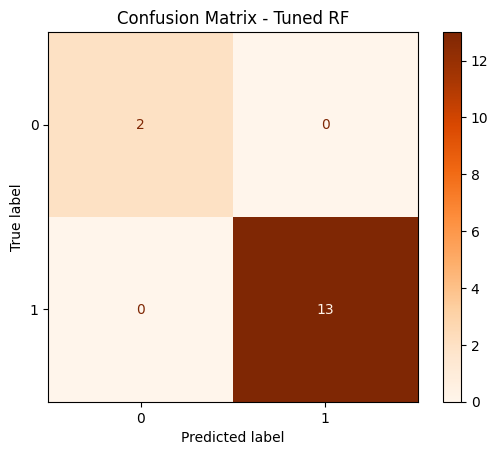

In [ ]:
# 9. Evaluate Tuned RF
# ----------------------------
best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test_pre)

print("\n=== Tuned RandomForest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

cm2 = confusion_matrix(y_test, y_pred_best)
disp2 = ConfusionMatrixDisplay(cm2)
disp2.plot(cmap='Oranges')
plt.title("Confusion Matrix - Tuned RF")
plt.show()

tuned_acc = accuracy_score(y_test, y_pred_best)
tuned_bal_acc = balanced_accuracy_score(y_test, y_pred_best)


=== Perbandingan Baseline vs Tuned ===
Baseline Accuracy: 1.0000 | Tuned Accuracy: 1.0000
Baseline Balanced Acc: 1.0000 | Tuned Balanced Acc: 1.0000


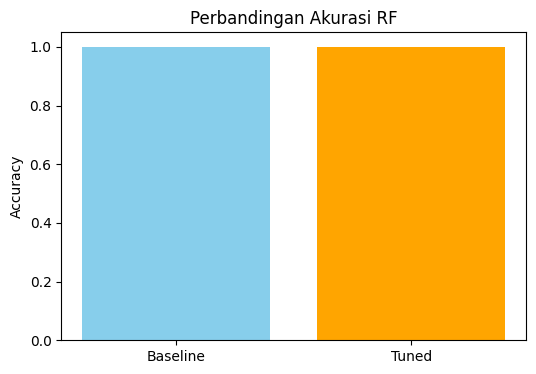

In [ ]:
# 10. Perbandingan hasil
# ----------------------------
print("\n=== Perbandingan Baseline vs Tuned ===")
print(f"Baseline Accuracy: {baseline_acc:.4f} | Tuned Accuracy: {tuned_acc:.4f}")
print(f"Baseline Balanced Acc: {baseline_bal_acc:.4f} | Tuned Balanced Acc: {tuned_bal_acc:.4f}")

plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Tuned"], [baseline_acc, tuned_acc], color=["skyblue", "orange"])
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi RF")
plt.show()

/tmp/ipython-input-2926534430.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index, palette="viridis")


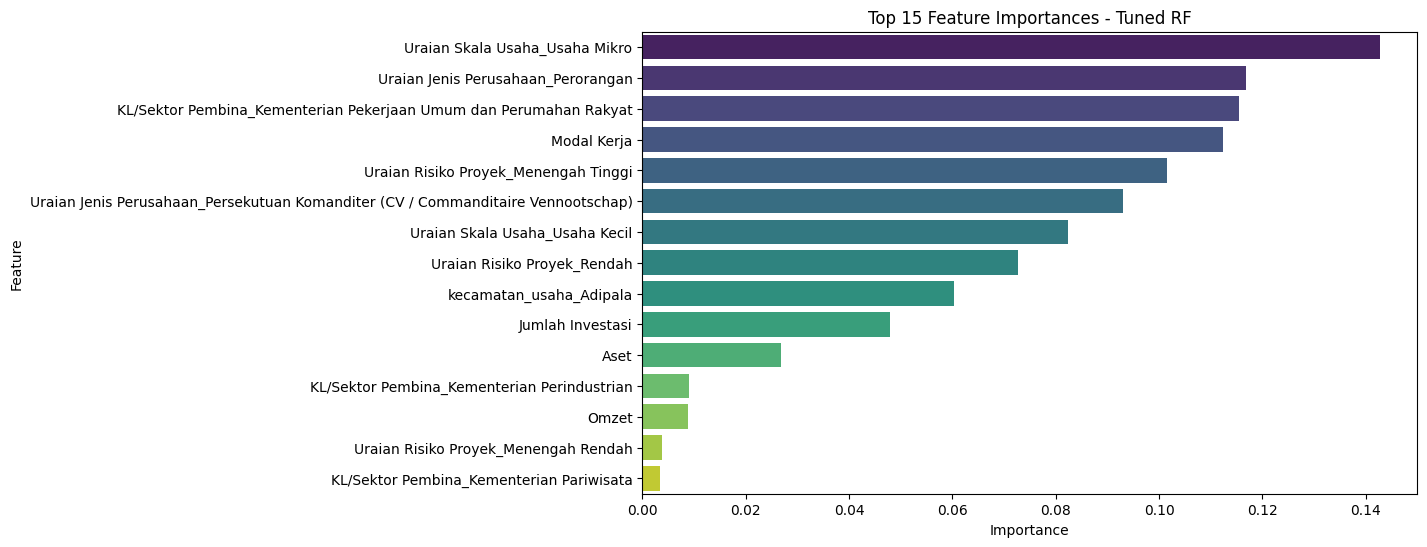

In [ ]:
# 11. Feature importance
# ----------------------------
ohe = pipeline_preprocess.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = list(ohe.get_feature_names_out(cat_features))
feature_names = list(num_features) + ohe_feature_names

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index, palette="viridis")
plt.title("Top 15 Feature Importances - Tuned RF")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# =========================================
# Clustering + RandomForest Pipeline
# Baseline vs Optimasi + ROC Curve
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    balanced_accuracy_score, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

# ----------------------------
# 1. Load Data
# ----------------------------
df1 = pd.read_csv("cluster_results.csv")
print("Data shape:", df1.shape)
print(df1.columns.tolist())

# ----------------------------
# 2. Feature selection (numeric & categorical)
# ----------------------------
num_features = ["Omzet", "Aset", "Jumlah tenaga kerja", "Modal Kerja", "Jumlah Investasi"]
cat_features = [
    "kecamatan_usaha",
    "Uraian Status Penanaman Modal",
    "Uraian Jenis Perusahaan",
    "Uraian Risiko Proyek",
    "KL/Sektor Pembina"
]
target_col = "Cluster"

# ----------------------------
# 3. Data cleaning
# ----------------------------
df1 = df1.dropna(subset=[target_col]).reset_index(drop=True)
df1[target_col] = df1[target_col].astype(int)

for c in num_features:
    df1[c] = pd.to_numeric(df1[c], errors='coerce')

df1 = df1.dropna(subset=num_features).reset_index(drop=True)

# ----------------------------
# 4. X, y preparation
# ----------------------------
X = df1[num_features + cat_features]
y = df1[target_col]

numeric_transformer = Pipeline([('scaler', StandardScaler())])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

# ----------------------------
# 5. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ----------------------------
# 6. Preprocess + SMOTE
# ----------------------------
pipeline_preprocess = Pipeline([('pre', preprocessor)])
X_train_pre = pipeline_preprocess.fit_transform(X_train)
X_test_pre = pipeline_preprocess.transform(X_test)

from collections import Counter

use_smote = True
if use_smote:
    class_counts = Counter(y_train)
    min_class_size = min(class_counts.values())
    k_neighbors = max(1, min(min_class_size - 1, 5))  # adaptif, aman untuk semua kelas
    print(f"SMOTE dijalankan dengan k_neighbors={k_neighbors}")
    sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_res, y_train_res = sm.fit_resample(X_train_pre, y_train)
else:
    X_train_res, y_train_res = X_train_pre, y_train


# ----------------------------
# Fungsi tambahan untuk hitung metrics
# ----------------------------
def print_metrics(y_true, y_pred, title="Metrics"):
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:\n", cm)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    # Specificity untuk multiclass dihitung one-vs-rest
    spec_list = []
    for i in range(len(np.unique(y_true))):
        tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        spec_list.append(spec)
    specificity = np.mean(spec_list)

    print(f"{title}:")
    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {prec:.4f}")
    print(f"Recall      : {rec:.4f}")
    print(f"Specificity : {specificity:.4f}")

    return acc, rec, specificity

# ----------------------------
# 7. Baseline RandomForest
# ----------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_pred = rf.predict(X_test_pre)

print("\n=== Baseline RandomForest ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Baseline RF")
plt.show()

baseline_acc = accuracy_score(y_test, y_pred)
baseline_bal_acc = balanced_accuracy_score(y_test, y_pred)

# ----------------------------
# 8. Hyperparameter tuning (Optimasi)
# ----------------------------
param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 8, 12, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    scoring='balanced_accuracy',
    cv=cv,
    random_state=42,
    verbose=1
)

rs.fit(X_train_res, y_train_res)
print("Best params:", rs.best_params_)
print("Best CV score:", rs.best_score_)

# ----------------------------
# 9. Evaluate Tuned RF
# ----------------------------
best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test_pre)

print("\n=== Tuned RandomForest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

cm2 = confusion_matrix(y_test, y_pred_best)
disp2 = ConfusionMatrixDisplay(cm2)
disp2.plot(cmap='Oranges')
plt.title("Confusion Matrix - Tuned RF")
plt.show()

tuned_acc = accuracy_score(y_test, y_pred_best)
tuned_bal_acc = balanced_accuracy_score(y_test, y_pred_best)

# ----------------------------
# 10. Perbandingan hasil
# ----------------------------
print("\n=== Perbandingan Baseline vs Tuned ===")
print(f"Baseline Accuracy: {baseline_acc:.4f} | Tuned Accuracy: {tuned_acc:.4f}")
print(f"Baseline Balanced Acc: {baseline_bal_acc:.4f} | Tuned Balanced Acc: {tuned_bal_acc:.4f}")

plt.figure(figsize=(6,4))
plt.bar(["Baseline", "Tuned"], [baseline_acc, tuned_acc], color=["skyblue", "orange"])
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi RF")
plt.show()

# ----------------------------
# 11. Feature importance
# ----------------------------
ohe = pipeline_preprocess.named_steps['pre'].named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = list(ohe.get_feature_names_out(cat_features))
feature_names = list(num_features) + ohe_feature_names

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index, palette="viridis")
plt.title("Top 15 Feature Importances - Tuned RF")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ----------------------------
# 12. ROC Curve multi-class
# ----------------------------
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = best_rf.predict_proba(X_test_pre)

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8,6))
colors = sns.color_palette("tab10", n_classes)

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"ROC Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot(fpr["micro"], tpr["micro"],
         label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})",
         color="black", linestyle="--", lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve per Kelas - Tuned RF")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ----------------------------
# 13. Save model & preprocessing
# ----------------------------
joblib.dump(best_rf, "rf_best_model.joblib")
pipeline_preprocess.fit(X)
joblib.dump(pipeline_preprocess, "preprocessing_pipeline.joblib")
print("\nModel & preprocessing pipeline berhasil disimpan.")


FileNotFoundError: [Errno 2] No such file or directory: 'cluster_results.csv'